In [127]:
import ee
import geemap
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

# Initialize Earth Engine with your registered Community Project ID
EE_PROJECT_ID = 'tree-505612'
try:
    ee.Initialize(project=EE_PROJECT_ID)
except Exception:
    ee.Authenticate(auth_mode='notebook')
    ee.Initialize(project=EE_PROJECT_ID)
print("GEE Initialized.")


GEE Initialized.


In [128]:
# Load CSV from your active Colab directory
df_trees = pd.read_csv('trees-with-species-and-dimensions-urban-forest.csv', sep=',')

# Filter strictly to trees planted in or before 2018 (matching thermal image year)
df_trees['year_clean'] = pd.to_datetime(df_trees['date_planted'], errors='coerce').dt.year
df_2018 = df_trees[(df_trees['year_clean'] <= 2018) | (df_trees['year_clean'].isna())].copy()

# Build spatial GeoDataFrame and reproject to metric meters (EPSG:7855)
trees_gdf = gpd.GeoDataFrame(
    df_2018,
    geometry=gpd.points_from_xy(df_2018['longitude'], df_2018['latitude']),
    crs="EPSG:4326"
).to_crs(epsg=7855)

# Calculate local neighborhood spacing via KNN (k=6 -> self + 5 closest)
coords = np.column_stack((trees_gdf.geometry.x, trees_gdf.geometry.y))
distances, _ = NearestNeighbors(n_neighbors=6, algorithm='ball_tree').fit(coords).kneighbors(coords)
trees_gdf['avg_dist_to_5_trees'] = distances[:, 1:].mean(axis=1)

print(f"Processed valid 2018 trees: {len(trees_gdf)}")

Processed valid 2018 trees: 61681


In [133]:
import geemap

# Convert a safe random sample into Earth Engine objects
sample_subset = trees_gdf.sample(n=15000, random_state=42)
ee_points = geemap.gdf_to_ee(sample_subset[['avg_dist_to_5_trees', 'geometry']])

# Pull peak summer 2018 Landsat 8 Collection 2 Tier 1 Level 2 (T1_L2) median composite
melbourne_geom = ee.Geometry.Point([144.9631, -37.8136]).buffer(15000)
l8_thermal = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
    .filterBounds(melbourne_geom) \
    .filterDate('2018-01-01', '2018-03-31') \
    .select('ST_B10') \
    .median()

# Extract pixel temperature directly under each individual tree point
sampled_ee = l8_thermal.sampleRegions(collection=ee_points, scale=30, geometries=True)
df_final = geemap.ee_to_gdf(sampled_ee)

# Convert Digital Number / Kelvin proxy to clean Celsius scale conversion using official USGS scale factors
df_final['Temp_C'] = (df_final['ST_B10'] * 0.00341802 + 149.0) - 273.15
print(f"Successfully mapped per-tree thermal pixels: {len(df_final)}")

Successfully mapped per-tree thermal pixels: 15000


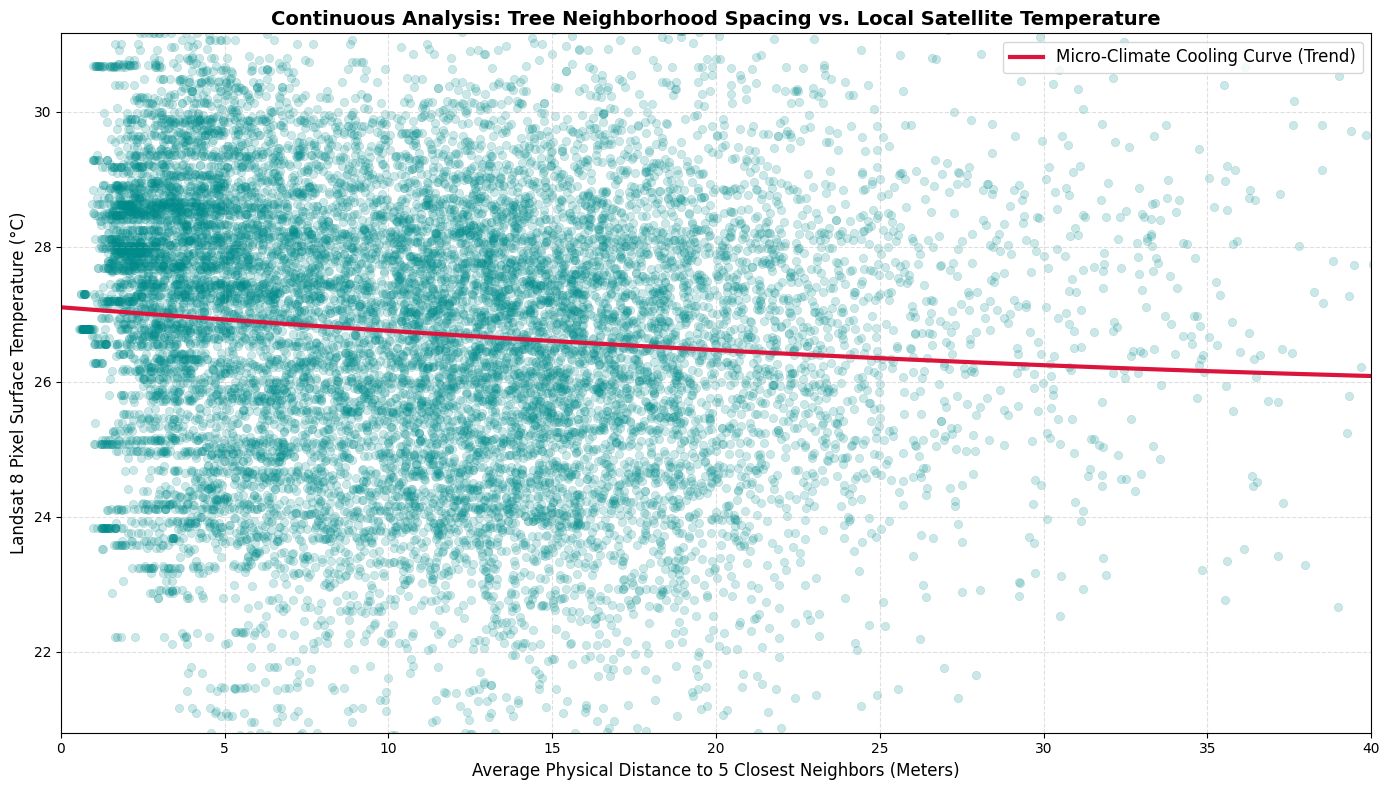

In [134]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

# 1. Plot the 15,000 individual trees as continuous points
sns.scatterplot(
    data=df_final,
    x='avg_dist_to_5_trees',
    y='Temp_C',
    alpha=0.2,
    color='darkcyan',
    edgecolor=None
)

# 2. Fit and overlay a Non-Linear Polynomial Trend Line (Degree = 2)
x_clean = df_final['avg_dist_to_5_trees'].dropna()
y_clean = df_final['Temp_C'].dropna()

poly_coefficients = np.polyfit(x_clean, y_clean, deg=2)
poly_function = np.poly1d(poly_coefficients)

# Generate smooth X values from 0 up to 40 meters to plot the curve line
x_trend = np.linspace(0, 40, 500)
y_trend = poly_function(x_trend)

plt.plot(x_trend, y_trend, color='crimson', linewidth=3, label='Micro-Climate Cooling Curve (Trend)')

# 3. Polish and format the graph canvas
plt.title('Continuous Analysis: Tree Neighborhood Spacing vs. Local Satellite Temperature', fontsize=14, fontweight='bold')
plt.xlabel('Average Physical Distance to 5 Closest Neighbors (Meters)', fontsize=12)
plt.ylabel('Landsat 8 Pixel Surface Temperature (°C)', fontsize=12)

# Set realistic street boundaries so extreme spacing outliers don't crush the view
plt.xlim(0, 40)
plt.ylim(df_final['Temp_C'].quantile(0.01), df_final['Temp_C'].quantile(0.99)) # Trims vertical edge noise

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()

plt.show()

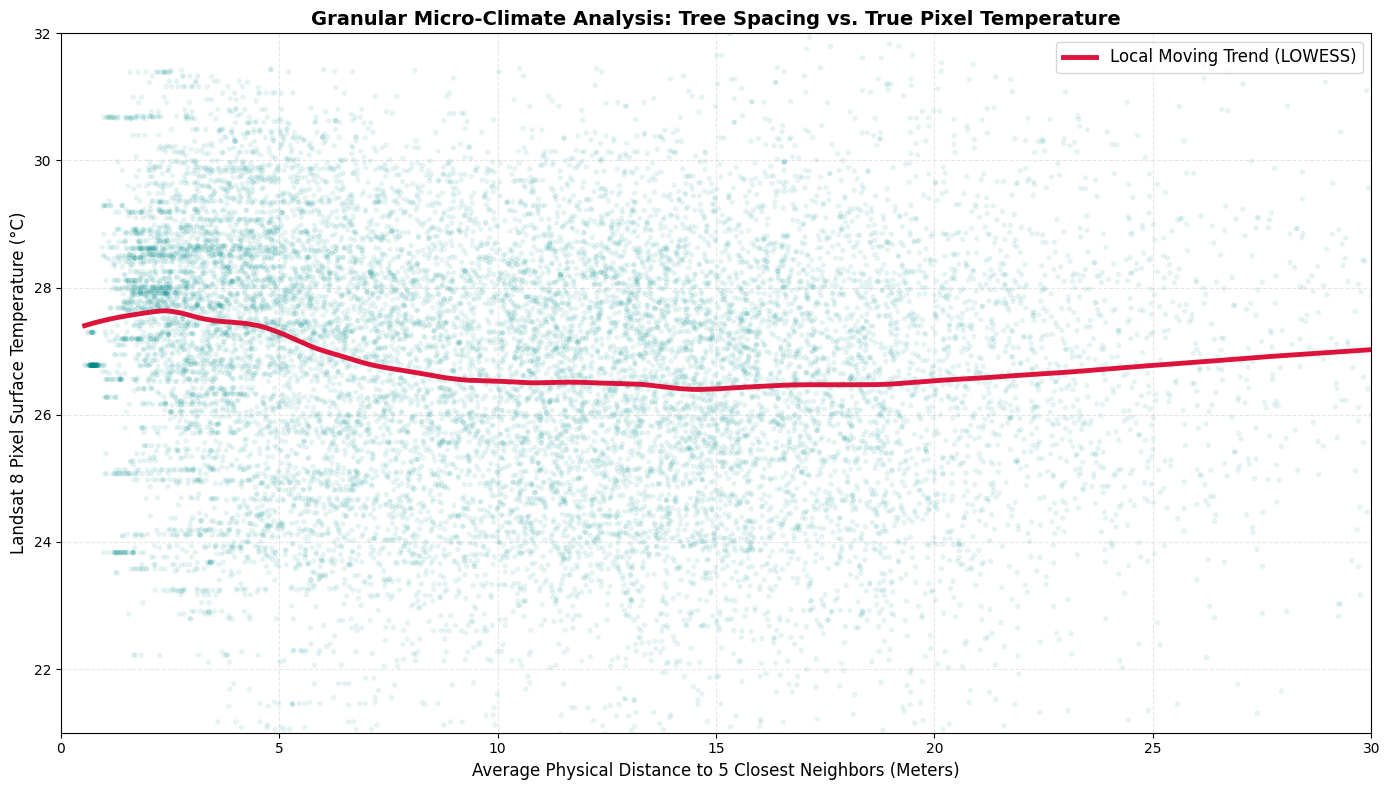

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np

plt.figure(figsize=(14, 8))

# 1. Plot the raw tree points with a lighter alpha (0.1) so the dense core stands out
plt.scatter(
    df_final['avg_dist_to_5_trees'],
    df_final['Temp_C'],
    alpha=0.1,
    color='darkcyan',
    s=15,
    edgecolor='none'
)

# 2. Compute a moving LOWESS curve to capture micro-shifts in the dense cloud core
x_clean = df_final['avg_dist_to_5_trees'].dropna()
y_clean = df_final['Temp_C'].dropna()

# Sort values for the smoother
sort_idx = np.argsort(x_clean)
x_sorted = x_clean.iloc[sort_idx]
y_sorted = y_clean.iloc[sort_idx]

# lowess low fraction (0.2) allows the line to bend locally to capture the sweet spot
lowess = sm.nonparametric.lowess(y_sorted, x_sorted, frac=0.2)

plt.plot(lowess[:, 0], lowess[:, 1], color='crimson', linewidth=3.5, label='Local Moving Trend (LOWESS)')

# 3. Canvas Polish
plt.title('Granular Micro-Climate Analysis: Tree Spacing vs. True Pixel Temperature', fontsize=14, fontweight='bold')
plt.xlabel('Average Physical Distance to 5 Closest Neighbors (Meters)', fontsize=12)
plt.ylabel('Landsat 8 Pixel Surface Temperature (°C)', fontsize=12)
plt.xlim(0, 30) # Crop closer to the active street zones
plt.ylim(21, 32)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()

plt.show()

In [136]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

print("Training final Machine Learning model on your spacing spectrum... 🌲")

# 1. Drop missing rows
ml_df = df_final[['avg_dist_to_5_trees', 'Temp_C']].dropna()

X = ml_df[['avg_dist_to_5_trees']]
y = ml_df['Temp_C']

# 2. Split data 80/20 train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Fit the curve using a non-linear tree regressor
rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

# 4. Score the results
preds = rf.predict(X_test)
print("\n--- 🏁 FINAL MODEL METRICS ---")
print(f"Model Mean Absolute Error: {mean_absolute_error(y_test, preds):.2f}°C")
print(f"Model Explanatory Power (R²): {r2_score(y_test, preds):.3f}")

Training final Machine Learning model on your spacing spectrum... 🌲

--- 🏁 FINAL MODEL METRICS ---
Model Mean Absolute Error: 1.71°C
Model Explanatory Power (R²): 0.047
